In [31]:
import numpy as np
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.globals as gl
import Functional_Fusion.dataset as fdata
import nibabel as nb
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [14]:
# Load X data
fname = gl.conn_dir + "/maps/MdWfIbDeHtNiSoScLa_fixSTD_cortex.pscalar.nii"
X = nb.load(fname).get_fdata()
print(f"Shape of cortex data: {X.shape}")

Shape of cortex data: (1168, 1876)


In [15]:
# Load Y data
fname = gl.conn_dir + "/maps/MdWfIbDeHtNiSoScLa_fixSTD_cerebellum.dscalar.nii"
Y = nb.load(fname).get_fdata()
print(f"Shape of cerebellum data: {Y.shape}")

Shape of cerebellum data: (1168, 5446)


In [64]:
# Load networks
yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_Icosahedron1002.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
yeo_labels = yeo_img.header.get_axis(0).label[0]
print(f"Shape of Yeo network data: {yeo_data.shape}")

Shape of Yeo network data: (1876,)


In [35]:
# Principal components of Y
pca = PCA()
scores = pca.fit_transform(Y.T)     # voxel scores
PCs = pca.components_[:6].T         # activity patterns
explained_var_ratio = pca.explained_variance_ratio_[:6]

<Axes: >

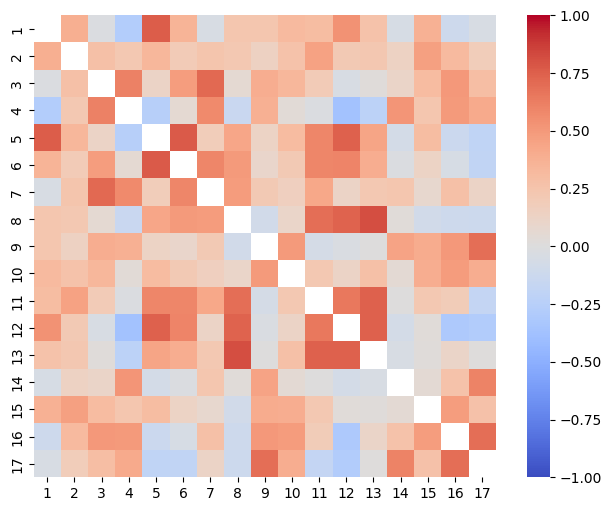

In [72]:
# Correlate X and Y
networks = np.zeros((X.shape[0], 17))
for i in range(17):
    networks[:, i] = np.nanmean(X[:, yeo_data == i+1], axis=1)

plt.figure(figsize=(8, 6))
sns.heatmap(np.corrcoef(networks.T), cmap='coolwarm', vmin=-1, vmax=1, square=True,
            mask=np.diag(np.ones(17, dtype=bool)), xticklabels=np.arange(1, 18), yticklabels=np.arange(1, 18))

<Axes: >

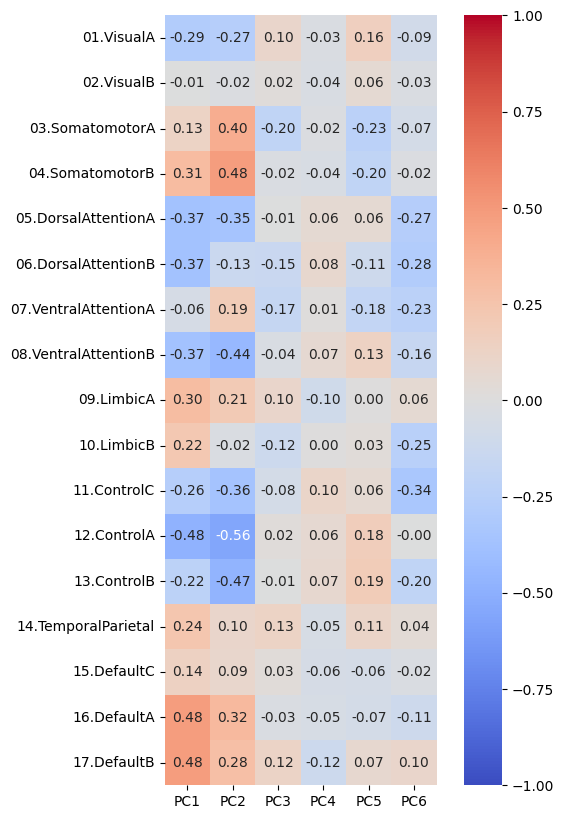

In [76]:
corr_map = np.zeros((17, 6))
for i in range(6):
    for n in range(17):
        corr_map[n, i] = np.corrcoef(PCs[:,i].T, networks[:,n].T)[0,1]

names = [yeo_labels[k][0] for k in yeo_labels][1:]
corr_df = pd.DataFrame(corr_map, columns=[f'PC{i+1}' for i in range(6)], index=names)

plt.figure(figsize=(7, 10))
sns.heatmap(corr_df, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)